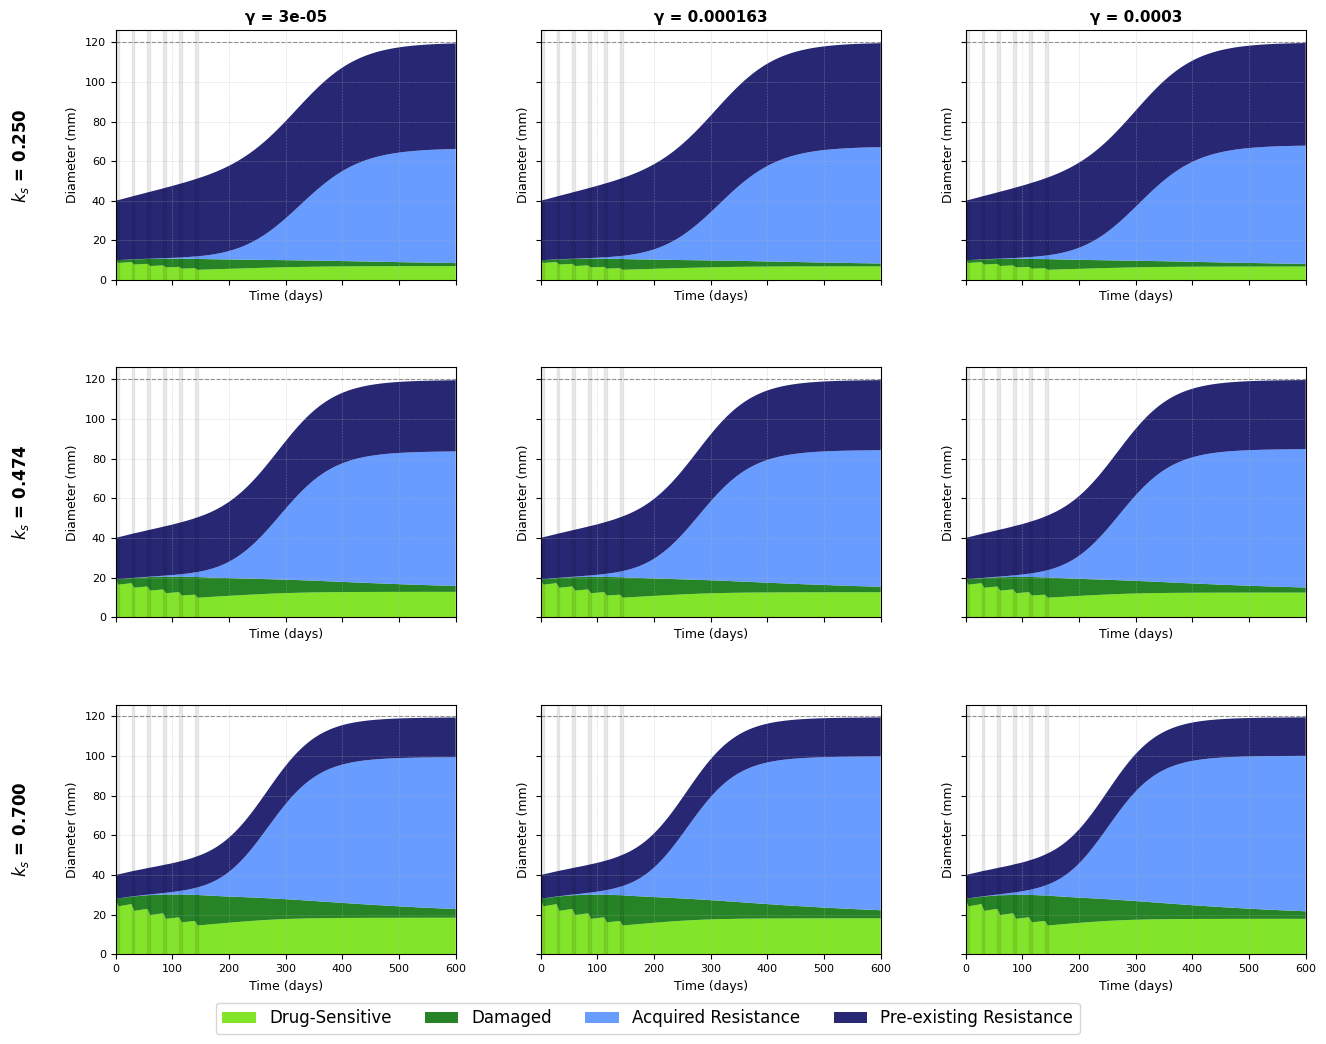

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

'''Parameters'''
# Tumor growth parameters
G = 0.003 # day^-1, proliferation rate
delta_RA = 11 # factor increase in proliferation rate for acquired resistant cells
tau_SD = 0.0382 # L/g/day, rate at which sensitive cells (S) are converted to damaged cells (D).
tau_DR = 0.000544 # day^-1, rate at which damaged cells (D) are converted to resistant cells (R).
mu_D = 0.00219 # day^-1, death rate for damaged cells (D)
gamma = 0.000136 # L/(mg·day), rate at which damaged cells can repair their DNA, allowing them to become resistant
k_s = 0.474 # proportion of P0 that is sensitive
P0 = 40 # mm, initial total tumour diameter
K = 120 # mm, carrying capacity

# Initial tumour cell conditions
S0 = k_s * P0
RP0 = (1 - k_s) * P0
D0 = 0
RA0 = 0

# Chemotherapeutic pharmacokinetics (PK) parameters
Ka = 5.8*24 # day^-1, absorption rate constant
CL = 10.0*24 # L/day, oral clearance
VD = 30.3 # L, volume of distribution in plasma/tissue
Vp = 0.14 # L, volume of distribution in CSF
k23 = 7.2e-4*24 # day^-1, transfer rate constant from the plasma to CSF
k32 = 0.14*24 # day^-1, back transfer rate constant from the CSF to plasma

'''Dosing Schedule'''
# 6 cycles, 175 mg/day for first 5 days of each 28-day cycle
DOSE_MG = 175.0 # dose (mg)
CYCLE_DAYS = 28
DOSE_DAYS = 5
N_CYCLES = 6
T_END = N_CYCLES * CYCLE_DAYS + 1000 # total days

def get_dose_times():
    """Return list of day numbers when a dose is given (day 0-indexed)."""
    times = []
    for c in range(N_CYCLES):
        start = c*CYCLE_DAYS
        for d in range(DOSE_DAYS):
            times.append(start + d)
    return times

'''Define ODEs that make up compartment model'''
# Drug compartments
def dA1(A1):
    return -Ka * A1

def dA2(A1, A2):
    return Ka * A1 - (CL / VD) * A2 - k23 * A2

def dA3(A2, A3):
    return k23 * A2 - k32 * A3

# Tumour compartments
def dS(S, N, C_CSF, G, tau_SD):
    return G * S * (1.0 - N / K) - tau_SD * C_CSF * S

def dD(S, D, C_CSF, tau_SD, tau_DR, mu_D, gamma):
    return tau_SD * C_CSF * S - (tau_DR + mu_D + gamma) * D

def dRA(RA, D, N, G, tau_DR, gamma, delta_RA):
    return G * (1 + delta_RA) * RA * (1.0 - N / K) + tau_DR * D + gamma * D

def dRP(RP, N, G):
    return G * RP * (1.0 - N / K)

'''Simulate and plot model'''
def simulate(ks, gam, t_end):
    
    # Starting sizes of each tumour compartment
    S0  = ks * P0
    RP0 = (1 - ks) * P0
    y0  = [S0, 0.0, 0.0, RP0, 0.0, 0.0, 0.0]  # [S, D, RA, RP, A1, A2, A3]

    # Get the list of days when a dose is given, and add the end day
    dose_times = get_dose_times()
    checkpoints = sorted(set(dose_times + [t_end]))

    # Define the ODEs to be solved
    def gbm_odes(t, y):
        S, D, RA, RP, A1, A2, A3 = y
        C_CSF = A3 / Vp
        N     = S + D + RA + RP
        return [
            dS(S, N, C_CSF, G, tau_SD),
            dD(S, D, C_CSF, tau_SD, tau_DR, mu_D, gam),
            dRA(RA, D, N, G, tau_DR, gam, delta_RA),
            dRP(RP, N, G),
            dA1(A1),
            dA2(A1, A2),
            dA3(A2, A3),
        ]

    # Solve the ODEs in segments between each dose/checkpoint
    # We do this so we can add the drug dose at each dosing time
    all_t, all_y = [], []
    t_now = 0.0
    y_now = np.array(y0)

    for t_next in checkpoints:

        # Solve from t_now to t_next using the Runge-Kutta method
        sol = solve_ivp(gbm_odes, [t_now, t_next], y_now, method='RK45')

        # Save results (drop last point to avoid duplicates at boundaries)
        all_t.append(sol.t[:-1])
        all_y.append(sol.y[:, :-1])

        # Move forward to t_next
        t_now = sol.t[-1]
        y_now = sol.y[:, -1].copy()

        # If this is a dosing day, add the drug to compartment A1
        if t_next in dose_times and t_next < t_end:
            y_now[4] += DOSE_MG

    # Add the final time point and stitch all segments together
    all_t.append([t_now])
    all_y.append(y_now.reshape(-1, 1))

    t = np.concatenate(all_t)
    y = np.concatenate(all_y, axis=1)

    return t, y

def plot_parameter_sweep():
    """3×3 grid of tumour composition plots with varying k_s (rows) and gamma (columns)."""
    ks_values    = [0.250, 0.474, 0.700]
    gamma_values = [0.00003, 0.000163, 0.0003]
    T_SWEEP      = 600  # days to show on x-axis

    # Colours for each tumour compartment
    colours = {
        "S":  "#6DE103",  # sensitive
        "D":  "#006F00",  # damaged
        "RA": "#4D8CFF",  # acquired resistance
        "RP": "#01015C",  # initial resistance
    }

    # Create the 3x3 grid of plots
    fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True, sharey=True)

    # Loop over each row (k_s) and column (gamma) combination
    for row, ks_val in enumerate(ks_values):
        for col, gam_val in enumerate(gamma_values):
            ax = axes[row][col]

            # Run the simulation with this combination of parameters
            t, y = simulate(ks_val, gam_val, T_SWEEP)
            S, D, RA, RP = y[0], y[1], y[2], y[3]

            # Plot tumour compartments as a stacked area chart
            ax.stackplot(t, S, D, RA, RP,
                         colors=[colours["S"], colours["D"], colours["RA"], colours["RP"]],
                         alpha=0.85)

            # Show the carrying capacity as a dashed line
            ax.axhline(K, color="black", lw=0.8, linestyle="--", alpha=0.4)

            # Shade the 5-day dosing windows for each cycle
            for c in range(N_CYCLES):
                start = c * CYCLE_DAYS
                end   = start + DOSE_DAYS
                if start < T_SWEEP:
                    ax.axvspan(start, min(end, T_SWEEP), alpha=0.075, color="black")

            # Set axis limits and labels
            ax.set_xlim(0, T_SWEEP)
            ax.set_ylim(0, K * 1.05)
            ax.set_xlabel("Time (days)", fontsize=9)
            ax.set_ylabel("Diameter (mm)", fontsize=9)
            ax.grid(linewidth=0.4, linestyle="--", alpha=0.5)
            ax.tick_params(labelsize=8)

            # Add column title (gamma value) on top row only
            if row == 0:
                ax.set_title(f"γ = {gam_val:.5g}", fontsize=11, fontweight="bold")

            # Add row label (k_s value) on left column only
            if col == 0:
                ax.text(-0.28, 0.5, f"$k_s$ = {ks_val:.3f}",
                        transform=ax.transAxes, fontsize=12, fontweight="bold",
                        va="center", ha="center", rotation=90)

    # Add a legend at the bottom of the figure
    legend_elements = [
        mpatches.Patch(facecolor=colours["S"],  alpha=0.85, label="Drug-Sensitive"),
        mpatches.Patch(facecolor=colours["D"],  alpha=0.85, label="Damaged"),
        mpatches.Patch(facecolor=colours["RA"], alpha=0.85, label="Acquired Resistance"),
        mpatches.Patch(facecolor=colours["RP"], alpha=0.85, label="Pre-existing Resistance"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.09, hspace=0.35, wspace=0.25)

'''Run and plot model'''
plot_parameter_sweep()